<a href="https://colab.research.google.com/github/Dockby/Coffee_sales_Analysis/blob/main/Coffee_Shop_analysis_practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

    order_id  date_time  drink_type    size  price  quantity barista_id  \
0          1 2024-01-01    Espresso   Small   3.50         1        B01   
1          2 2024-01-01       Latte  Medium   5.00         2        B02   
2          3 2024-01-01   Cold Brew   Large   6.00         1        B01   
3          4 2024-01-02       Latte   Small   4.50         1        B03   
4          5 2024-01-02    Espresso  Medium   4.88         1        B02   
5          6 2024-01-02  Cappuccino   Large   6.50         1        B01   
6          7 2024-01-03   Cold Brew   Small   4.00         2        B03   
7          8 2024-01-03       Latte   Large   6.00         1          0   
8          9 2024-01-03    Espresso   Small   3.50         1        B02   
9         10 2024-01-04  Cappuccino  Medium   5.50         1        B01   
10        11 2024-01-04       Latte  Medium   5.00         3        B03   
11        12 2024-01-04   Cold Brew   Large   6.00         1        B02   
12        13 2024-01-05  

/tmp/ipykernel_933/1226510047.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['price'].fillna(data['price'].mean(),inplace=True)
/tmp/ipykernel_933/1226510047.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)

Text(0, 0.5, 'type')

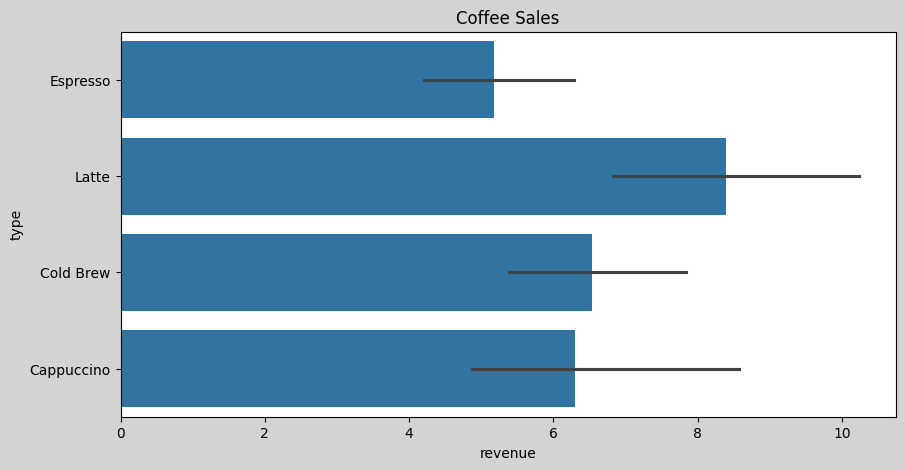

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns



data=pd.read_csv("/content/coffee_sales.csv")


data['price'].fillna(data['price'].mean(),inplace=True)
data['barista_id'].fillna(0,inplace=True)
data.rename(columns={'date':'date_time'},inplace=True)

data['revenue']=data['price']* data['quantity']

data['date_time'] = pd.to_datetime(data['date_time'])

data['day_of_week'] = data['date_time'].dt.day_name()
df_cleaned = data.drop_duplicates()

print(df_cleaned)
plt.figure(figsize=(10, 5), facecolor='lightgrey')
sns.barplot(data=data,x="revenue",y="drink_type")
plt.title("Coffee Sales")
plt.xlabel("revenue")
plt.ylabel("type")


Text(0, 0.5, 'size')

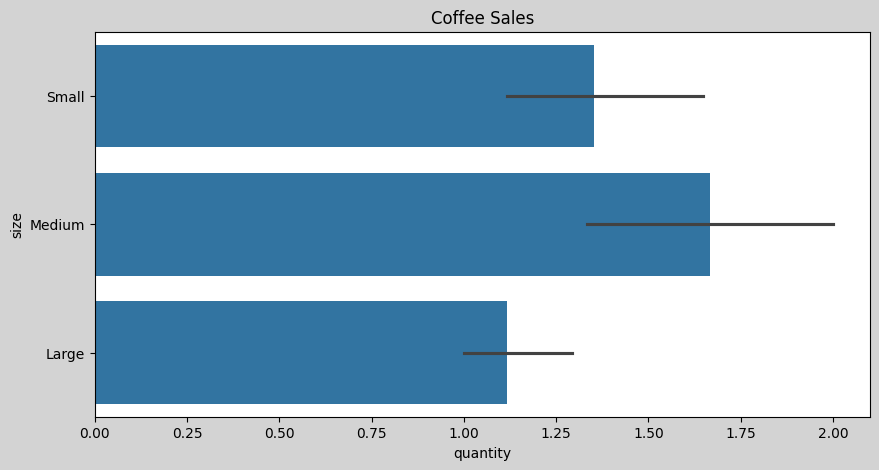

In [ ]:
plt.figure(figsize=(10, 5), facecolor='lightgrey')
sns.barplot(data=data,x="quantity",y="size")
plt.title("Coffee Sales")
plt.xlabel("quantity")
plt.ylabel("size")

In [ ]:
data.groupby('barista_id')['revenue'].max()

,revenue
barista_id,
0,10.0
B01,16.5
B02,12.0
B03,15.0


In [ ]:
data['payment_method'].value_counts().idxmax()

'Card'

In [ ]:
data.groupby('day_of_week')['revenue'].value_counts().idxmax()

('Monday', np.float64(6.0))

In [ ]:
data.sort_values(by='revenue', ascending=False).head(3)

,order_id,date_time,drink_type,size,price,quantity,barista_id,payment_method,revenue,day_of_week
34,35,2024-01-12,Cappuccino,Medium,5.5,3,B01,Cash,16.5,Friday
10,11,2024-01-04,Latte,Medium,5.0,3,B03,Cash,15.0,Thursday
51,11,2024-01-04,Latte,Medium,5.0,3,B03,Cash,15.0,Thursday
